# STEP 1 — Import Libraries

In [1]:
# Importing Basic libraries
import pandas as pd
import numpy as np

# Importing Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Machine Learning Libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Importing Clustering Libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ImportingHierarchical Clustering Libraries
from sklearn.cluster import AgglomerativeClustering

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


# STEP 2 — Upload Dataset to Google Colab

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Customer_segmentation_dataset.csv to Customer_segmentation_dataset (1).csv


# STEP 3 — Load Dataset

In [7]:
df = pd.read_csv("/content/Customer_segmentation_dataset.csv")
print("Dataset Loaded Successfully")
print ("shape:", df.shape)

Dataset Loaded Successfully
shape: (800, 16)


# STEP 4 — View First Few Records

In [8]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family_Size,Marital_Status,Preferred_Category,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,City_Tier,Discount_Usage_Rate,Credit_Score
0,1,Male,48,95857,78,Homemaker,30.0,2,Single,Home & Living,0.0,14,46,3,13.7,689
1,2,Female,37,31914,89,Homemaker,15.0,2,Divorced,Fashion,1.8,12,7,1,50.1,686
2,3,Female,33,76710,68,Teacher,12.0,2,Single,Groceries,5.1,11,2,2,1.1,729
3,4,Male,37,82276,93,Artist,14.0,3,Single,Electronics,3.4,7,50,2,15.5,663
4,5,Female,32,67215,83,Homemaker,9.0,3,Married,Home & Living,1.5,10,62,2,10.8,666


# STEP 5 — Understand Dataset

In [9]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 800
Number of Columns: 16


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              800 non-null    int64  
 1   Gender                  800 non-null    object 
 2   Age                     800 non-null    int64  
 3   Annual_Income           800 non-null    int64  
 4   Spending_Score          800 non-null    int64  
 5   Profession              800 non-null    object 
 6   Work_Experience         775 non-null    float64
 7   Family_Size             800 non-null    int64  
 8   Marital_Status          800 non-null    object 
 9   Preferred_Category      800 non-null    object 
 10  Membership_Years        785 non-null    float64
 11  Avg_Monthly_Visits      800 non-null    int64  
 12  Last_Purchase_Days_Ago  800 non-null    int64  
 13  City_Tier               800 non-null    int64  
 14  Discount_Usage_Rate     800 non-null    fl

In [11]:
df.describe()

,CustomerID,Age,Annual_Income,Spending_Score,Work_Experience,Family_Size,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,City_Tier,Discount_Usage_Rate,Credit_Score
count,800.0000,800.000000,800.000000,800.000000,775.000000,800.000000,785.000000,800.00000,800.000000,800.00000,800.000000,800.000000
mean,400.5000,40.191250,54394.206250,49.810000,17.858065,2.872500,3.057197,5.35625,18.467500,1.69250,28.992000,678.421250
std,231.0844,11.468504,27836.284714,28.482151,11.288122,1.784019,1.910778,3.71707,18.355656,0.77051,17.779216,42.511767
min,1.0000,18.000000,14130.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,1.00000,0.000000,539.000000
25%,200.7500,32.000000,28520.000000,23.000000,9.000000,1.000000,1.700000,2.00000,5.000000,1.00000,15.850000,649.000000
50%,400.5000,40.000000,50981.000000,51.000000,17.000000,2.000000,2.900000,5.00000,12.000000,2.00000,26.250000,677.500000
75%,600.2500,49.000000,77352.000000,76.000000,26.000000,4.000000,4.400000,8.00000,28.000000,2.00000,41.225000,708.000000
max,800.0000,70.000000,275495.000000,100.000000,50.000000,10.000000,10.300000,16.00000,113.000000,3.00000,78.800000,806.000000


For categorical variables:

In [12]:
df.describe(include='object')

,Gender,Profession,Marital_Status,Preferred_Category
count,800,800,800,800
unique,2,10,3,8
top,Male,Teacher,Married,Travel
freq,410,96,365,111


# STEP 6 — Check Column Names

In [13]:
df.columns.tolist()

['CustomerID',
 'Gender',
 'Age',
 'Annual_Income',
 'Spending_Score',
 'Profession',
 'Work_Experience',
 'Family_Size',
 'Marital_Status',
 'Preferred_Category',
 'Membership_Years',
 'Avg_Monthly_Visits',
 'Last_Purchase_Days_Ago',
 'City_Tier',
 'Discount_Usage_Rate',
 'Credit_Score']

# STEP 7 — Check Missing Values

In [14]:
missing_values = df.isnull().sum()
print(missing_values)


CustomerID                 0
Gender                     0
Age                        0
Annual_Income              0
Spending_Score             0
Profession                 0
Work_Experience           25
Family_Size                0
Marital_Status             0
Preferred_Category         0
Membership_Years          15
Avg_Monthly_Visits         0
Last_Purchase_Days_Ago     0
City_Tier                  0
Discount_Usage_Rate        0
Credit_Score               0
dtype: int64


# STEP 8 — Visualize Missing Values

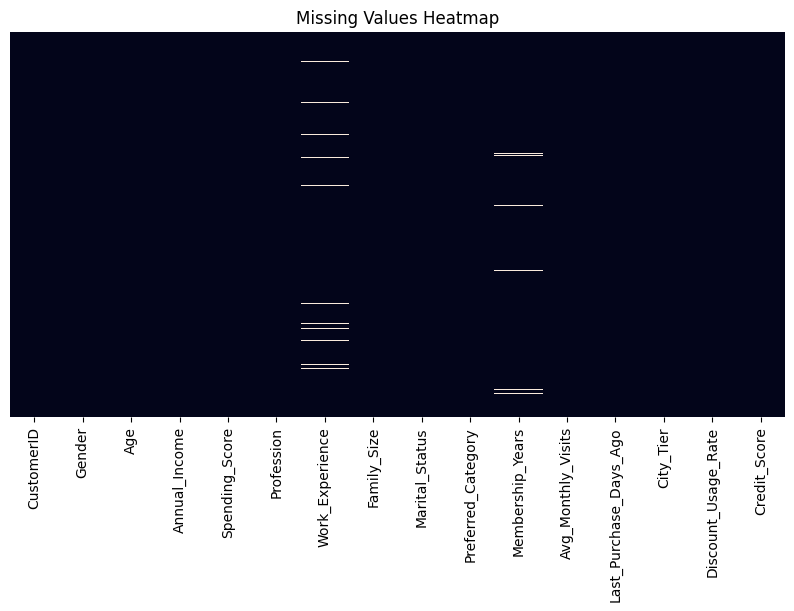

In [15]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()


# STEP 9 — Check Duplicate Records

In [16]:
print("Number of Duplicate Records:", df.duplicated().sum())

Number of Duplicate Records: 0


# STEP 10 — Check Unique Values of Categorical Variables

In [17]:
categorical_columns = [
    'Gender',
    'Profession',
    'Marital_Status',
    'Preferred_Category'
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Gender
Gender
Male      410
Female    390
Name: count, dtype: int64

 Profession
Profession
Teacher         96
Artist          90
Engineer        88
Homemaker       83
Retired         82
Doctor          76
Entrepreneur    74
Lawyer          72
Executive       71
Student         68
Name: count, dtype: int64

 Marital_Status
Marital_Status
Married     365
Single      350
Divorced     85
Name: count, dtype: int64

 Preferred_Category
Preferred_Category
Travel           111
Books            107
Electronics      103
Beauty           103
Sports           100
Fashion           94
Groceries         91
Home & Living     91
Name: count, dtype: int64


# STEP 11 — Analyze Numeric Variables

In [18]:
numeric_columns = [
    'Age',
    'Annual_Income',
    'Spending_Score',
    'Work_Experience',
    'Family_Size',
    'Membership_Years',
    'Avg_Monthly_Visits',
    'Last_Purchase_Days_Ago',
    'City_Tier',
    'Discount_Usage_Rate',
    'Credit_Score'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,800.0,40.191250,11.468504,18.0,32.00,40.00,49.000,70.0
Annual_Income,800.0,54394.206250,27836.284714,14130.0,28520.00,50981.00,77352.000,275495.0
Spending_Score,800.0,49.810000,28.482151,1.0,23.00,51.00,76.000,100.0
Work_Experience,775.0,17.858065,11.288122,0.0,9.00,17.00,26.000,50.0
Family_Size,800.0,2.872500,1.784019,1.0,1.00,2.00,4.000,10.0
Membership_Years,785.0,3.057197,1.910778,0.0,1.70,2.90,4.400,10.3
Avg_Monthly_Visits,800.0,5.356250,3.717070,0.0,2.00,5.00,8.000,16.0
Last_Purchase_Days_Ago,800.0,18.467500,18.355656,0.0,5.00,12.00,28.000,113.0
City_Tier,800.0,1.692500,0.770510,1.0,1.00,2.00,2.000,3.0
Discount_Usage_Rate,800.0,28.992000,17.779216,0.0,15.85,26.25,41.225,78.8


# STEP 12 — Distribution of Important Variables

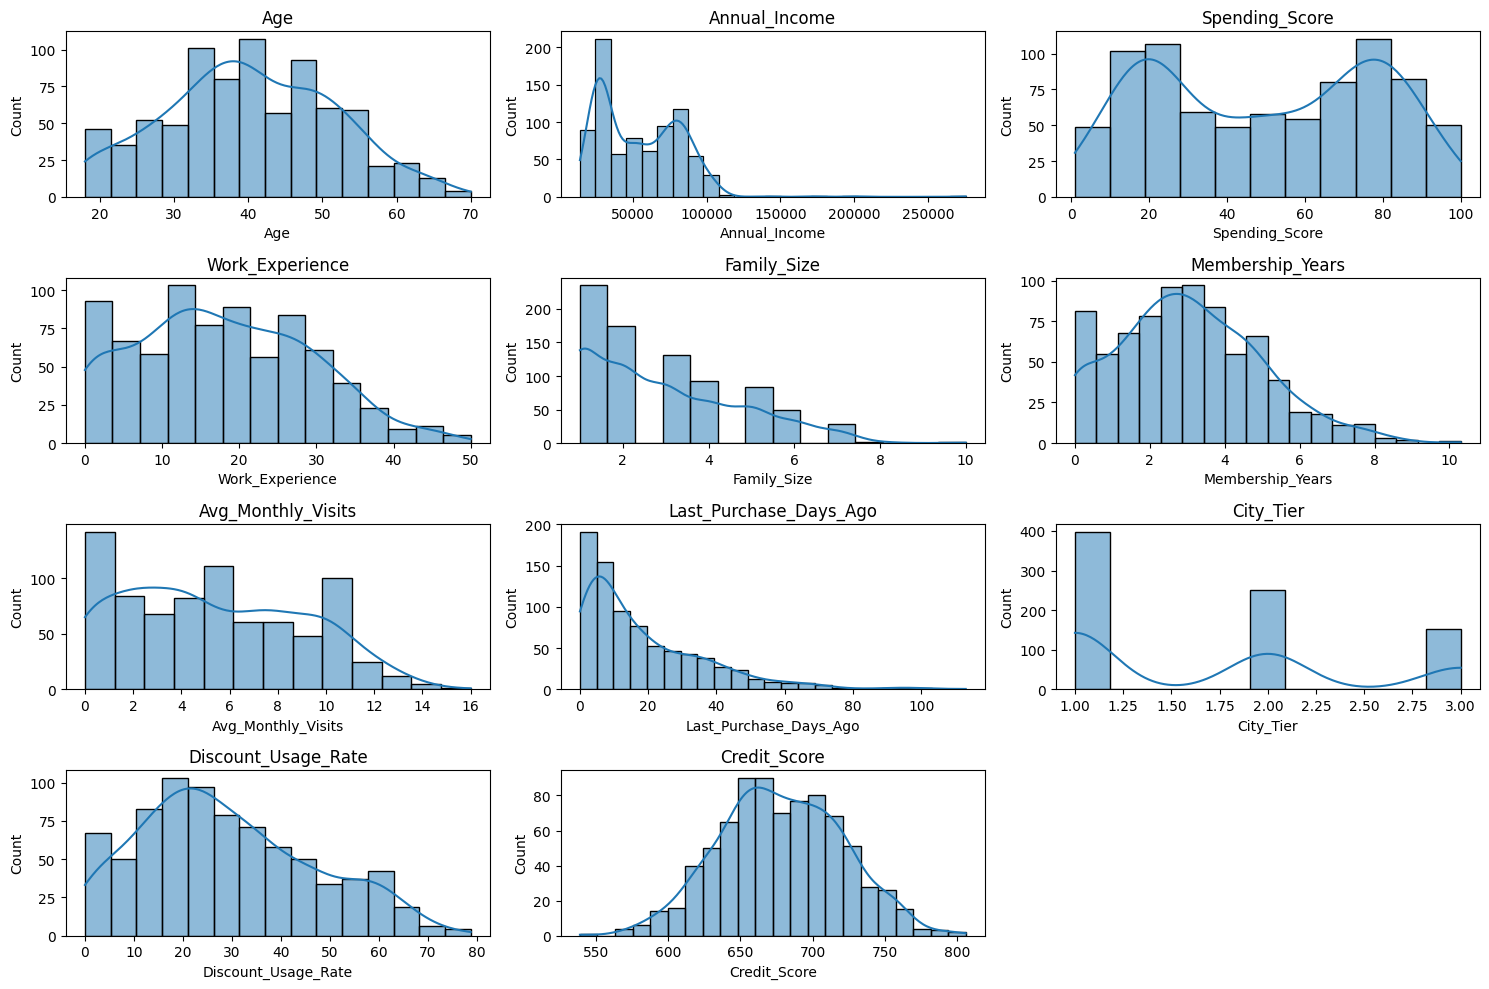

In [19]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

# STEP 13 — Annual Income Outlier Detection

In [20]:
#This project specifically asks us to detect and treat outliers in Annual_Income.
#We'll use the IQR method.

In [21]:
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 28520.0
Q3: 77352.0
IQR: 48832.0
Lower Limit: -44728.0
Upper Limit: 150600.0


# Outliers Detection

In [22]:
outliers = df[
    (df['Annual_Income'] < lower_limit) |
    (df['Annual_Income'] > upper_limit)
]

print("Number of Annual Income outliers:", len(outliers))

outliers[['CustomerID', 'Annual_Income']]

Number of Annual Income outliers: 3


,CustomerID,Annual_Income
396,397,200959
466,467,275495
753,754,172347


In [23]:
#In this dataset, there are a few unusually high-income customers.

# STEP 14 — Visualize Income Outliers

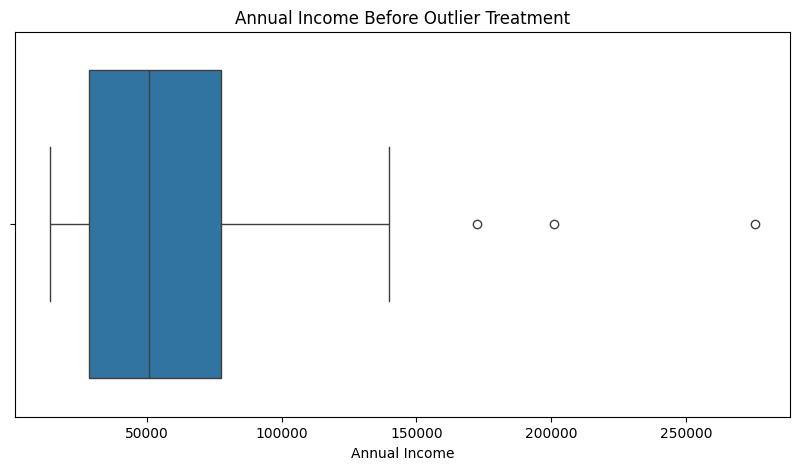

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Annual_Income'])

plt.title("Annual Income Before Outlier Treatment")
plt.xlabel("Annual Income")

plt.show()

# STEP 15 — Treat Annual Income Outliers

In [26]:
#Instead of deleting high income customers, we'll use capping/winsorization.
#This is preferable here because an extremely high-income customer is still a valid customer.

In [27]:
df['Annual_Income'] = df['Annual_Income'].clip(
    lower=lower_limit,
    upper=upper_limit
)

print("Outliers capped successfully.")

Outliers capped successfully.


# Checking (by visualize) the Annual Income Outlier after the capping treatment

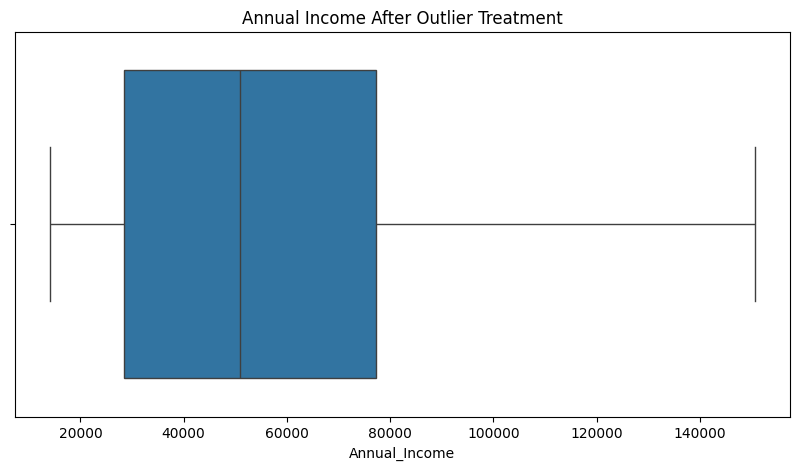

In [28]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Annual_Income'])

plt.title("Annual Income After Outlier Treatment")

plt.show()

# STEP 16 — Handle Missing Values

In [29]:
# We will use for Numerical Variables : Work Experience (Median)
# and for Categorical Variable : Membership_Years (Mode)
# Median Imputer will be suitable for above two terms

In [30]:
df['Work_Experience'] = df['Work_Experience'].fillna(
    df['Work_Experience'].median()
)

df['Membership_Years'] = df['Membership_Years'].fillna(
    df['Membership_Years'].median()
)

# Check again after the Median Imputation

In [31]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual_Income             0
Spending_Score            0
Profession                0
Work_Experience           0
Family_Size               0
Marital_Status            0
Preferred_Category        0
Membership_Years          0
Avg_Monthly_Visits        0
Last_Purchase_Days_Ago    0
City_Tier                 0
Discount_Usage_Rate       0
Credit_Score              0
dtype: int64


# STEP 17 — Explore Correlation for understanding relationship-Numerical Values

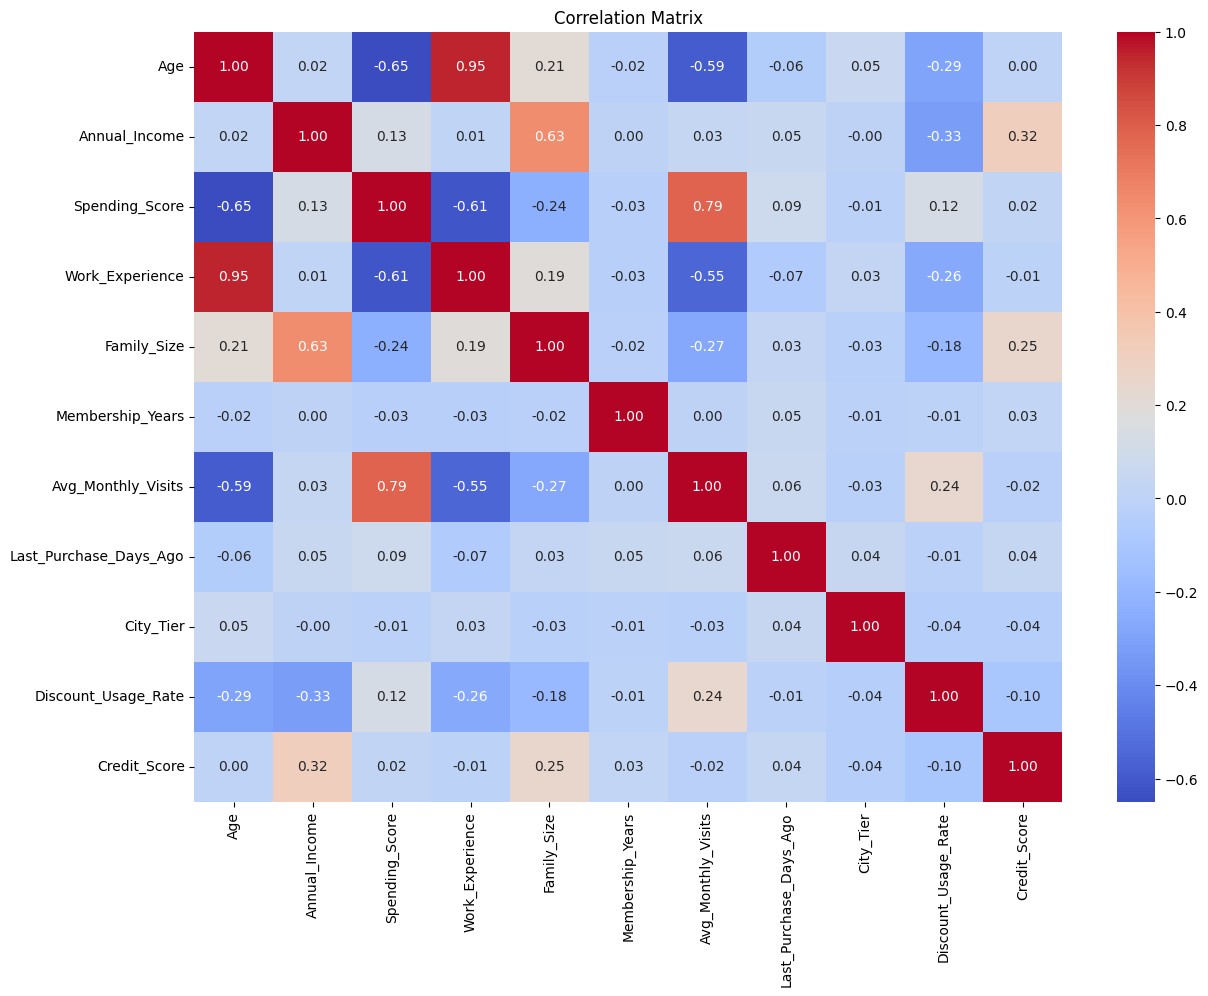

In [32]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# STEP 18 — Explore Important Relationships(for example : Income Vs Spending)

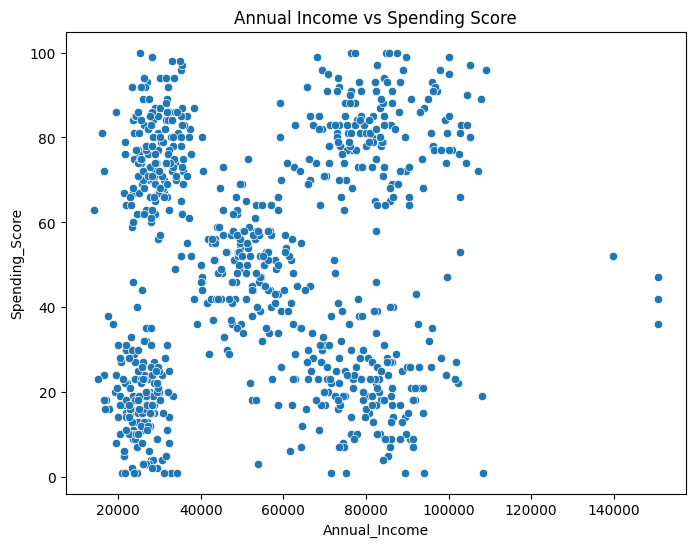

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score'
)

plt.title("Annual Income vs Spending Score")

plt.show()

# Age vs spending:

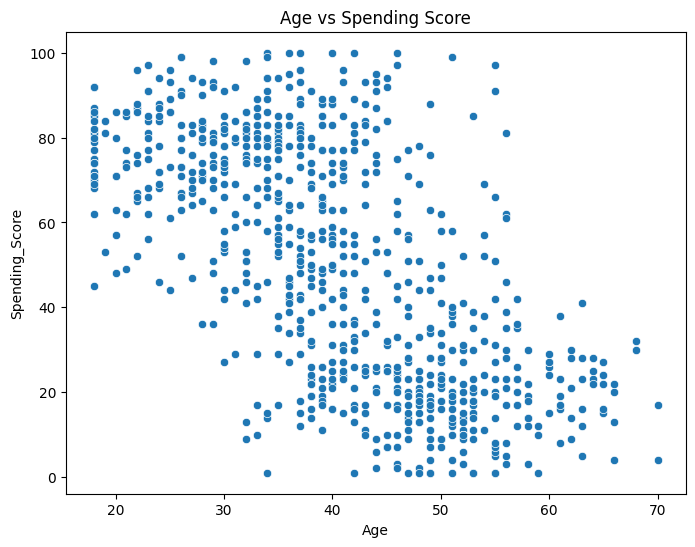

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Score'
)

plt.title("Age vs Spending Score")

plt.show()

# Visits vs spending:

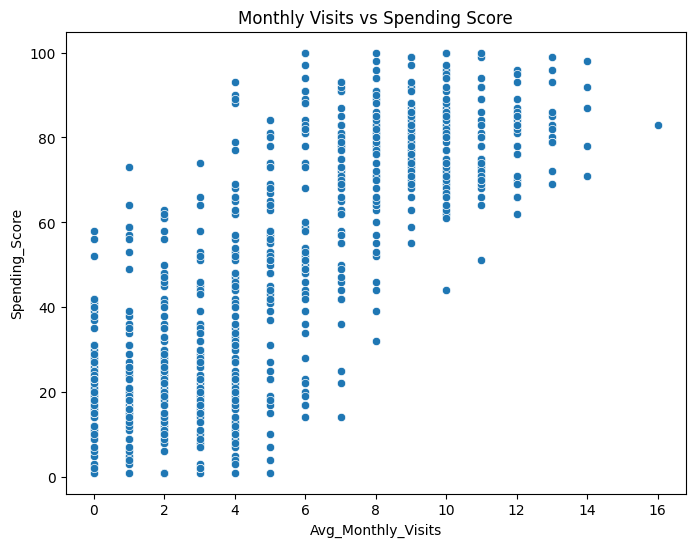

In [35]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Avg_Monthly_Visits',
    y='Spending_Score'
)

plt.title("Monthly Visits vs Spending Score")

plt.show()

# STEP 19 — Prepare Features for Clustering

In [36]:
# We should not use CustomerID for clustering
# Customer ID works as only the Identifier

X = df.drop(columns=['CustomerID'])

print(X.shape)

(800, 15)


# STEP 20 — Separate Numerical and Categorical Features

In [37]:
numeric_features = [
    'Age',
    'Annual_Income',
    'Spending_Score',
    'Work_Experience',
    'Family_Size',
    'Membership_Years',
    'Avg_Monthly_Visits',
    'Last_Purchase_Days_Ago',
    'City_Tier',
    'Discount_Usage_Rate',
    'Credit_Score'
]

categorical_features = [
    'Gender',
    'Profession',
    'Marital_Status',
    'Preferred_Category'
]

# STEP 21 — Encode Categorical Variables

In [38]:
#We will use One Hot Encoding
# Like, Gender : MALE , FEMALE

# STEP 22 — Scale Numerical Features

In [39]:
#This is very important for clustering
#Without Scaling Income may dominate the clustering algo
#We will use standardscaler

# STEP 23 — Create Preprocessing Pipeline

In [40]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [41]:
#Now we have to combine them:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# STEP 24 — Transform Dataset

In [42]:
X_processed = preprocessor.fit_transform(X)

print("Processed data shape:", X_processed.shape)

Processed data shape: (800, 34)


# STEP 25 — Convert to Dense Array (For easier visualization and some clustering algorithms:)

In [43]:
print("Type:", type(X_processed))

if hasattr(X_processed, "toarray"):
      print("Sparse matrix detected")
      X_processed = X_processed.toarray()
else:
      print("Already a NumPy array")

print("Shape:", X_processed.shape)

Type: <class 'numpy.ndarray'>
Already a NumPy array
Shape: (800, 34)


# STEP 26 — Determine Optimal Number of Clusters (We'll test different values of K.)

In [44]:
K = 2
K = 3
K = 4
...
K = 10

# STEP 27 — Elbow Method

In [45]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed)

    inertia.append(kmeans.inertia_)

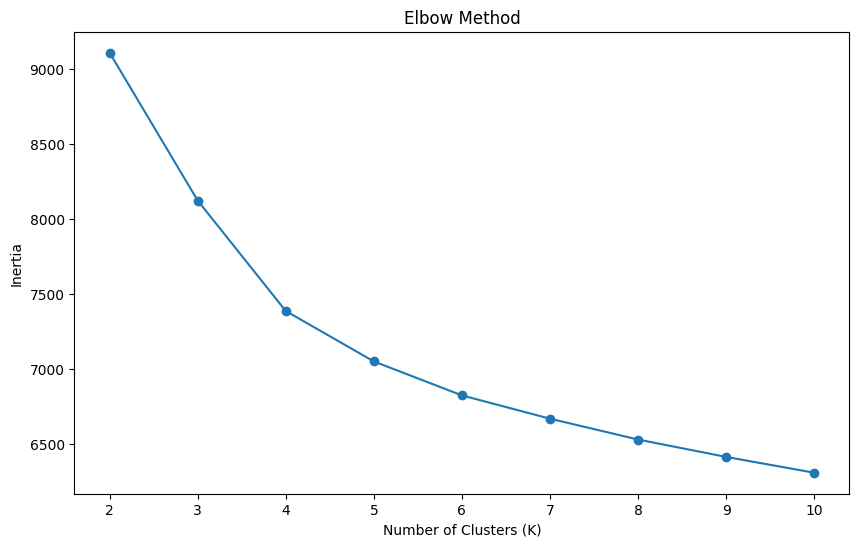

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(K_range)

plt.show()

# What are we looking for?
We look for the point where the reduction in inertia starts slowing down. This looks like an elbow.

# STEP 28 — Silhouette Score
# The Silhouette Score measures how well-separated the clusters are.
Higher is generally better.

In [47]:
silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    score = silhouette_score(
        X_processed,
        labels
    )

    silhouette_scores.append(score)

    print(
        "K =", k,
        "Silhouette Score =", round(score, 4)
    )

K = 2 Silhouette Score = 0.1621
K = 3 Silhouette Score = 0.1579
K = 4 Silhouette Score = 0.1577
K = 5 Silhouette Score = 0.1329
K = 6 Silhouette Score = 0.131
K = 7 Silhouette Score = 0.1165
K = 8 Silhouette Score = 0.113
K = 9 Silhouette Score = 0.0948
K = 10 Silhouette Score = 0.0821


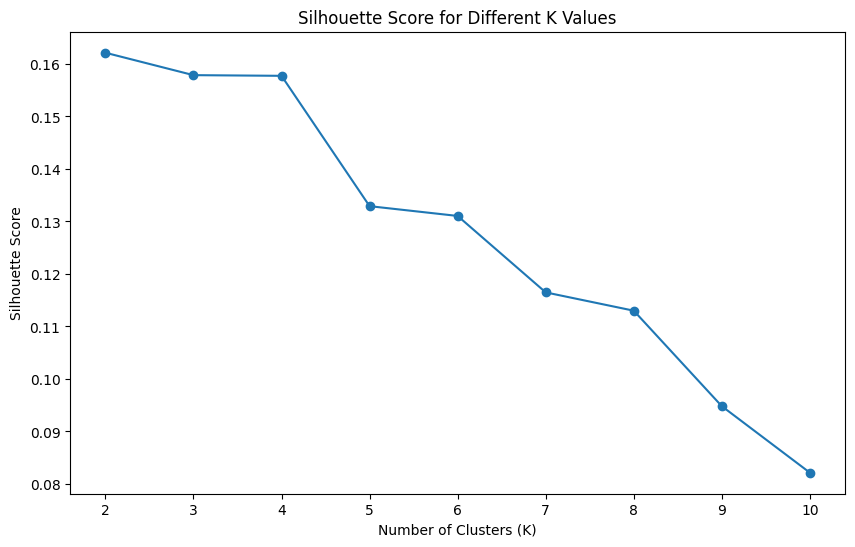

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Score for Different K Values")

plt.xticks(K_range)

plt.show()

# STEP 29 — Create a Comparison Table

In [49]:
cluster_evaluation = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertia,
    'Silhouette_Score': silhouette_scores
})

cluster_evaluation

,K,Inertia,Silhouette_Score
0,2,9107.070235,0.162138
1,3,8122.310223,0.157867
2,4,7386.679052,0.157738
3,5,7050.810651,0.132914
4,6,6824.662640,0.131050
5,7,6669.528081,0.116491
6,8,6530.586323,0.113003
7,9,6414.887697,0.094810
8,10,6309.562439,0.082145


Based on our actual dataset, the silhouette score is highest at K=2, although the elbow can suggest a somewhat larger segmentation depending on how we interpret the curve.
For a business segmentation project, it is recommended K=4 as a practical starting point if the elbow and segment interpretability support it, rather than blindly selecting the maximum silhouette score.

# STEP 30 — Train Final K-Means Model (We will use K=4)

In [50]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_processed)

print("K-Means clustering completed!")

K-Means clustering completed!


# STEP 31 — Add Cluster Labels

In [51]:
df['Cluster'] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family_Size,Marital_Status,Preferred_Category,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,City_Tier,Discount_Usage_Rate,Credit_Score,Cluster
0,1,Male,48,95857,78,Homemaker,30.0,2,Single,Home & Living,0.0,14,46,3,13.7,689,2
1,2,Female,37,31914,89,Homemaker,15.0,2,Divorced,Fashion,1.8,12,7,1,50.1,686,1
2,3,Female,33,76710,68,Teacher,12.0,2,Single,Groceries,5.1,11,2,2,1.1,729,2
3,4,Male,37,82276,93,Artist,14.0,3,Single,Electronics,3.4,7,50,2,15.5,663,2
4,5,Female,32,67215,83,Homemaker,9.0,3,Married,Home & Living,1.5,10,62,2,10.8,666,2


# STEP 32 — Check Number of Customers in Each Cluster

In [52]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,218
1,169
2,238
3,175


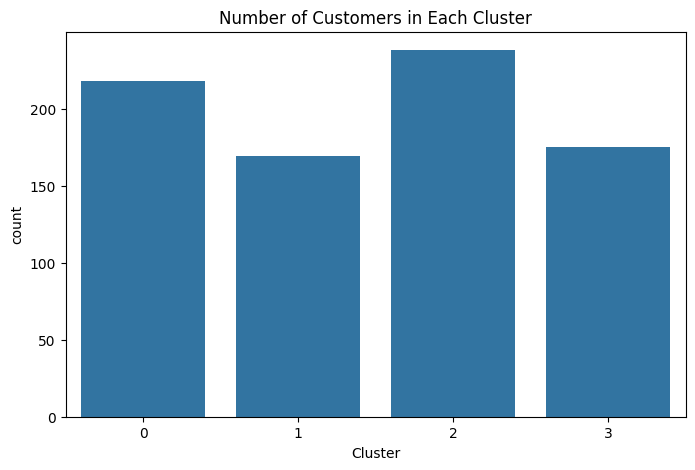

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Cluster'
)

plt.title("Number of Customers in Each Cluster")

plt.show()

# STEP 33 — Cluster Profiling

In [54]:
# This is one of the most important parts of the project.
# We want to understand:
"What type of customers are in each cluster?"

'What type of customers are in each cluster?'

In [55]:
cluster_profile = df.groupby('Cluster')[
    [
        'Age',
        'Annual_Income',
        'Spending_Score',
        'Work_Experience',
        'Family_Size',
        'Membership_Years',
        'Avg_Monthly_Visits',
        'Last_Purchase_Days_Ago',
        'Discount_Usage_Rate',
        'Credit_Score'
    ]
].mean().round(2)

cluster_profile

,Age,Annual_Income,Spending_Score,Work_Experience,Family_Size,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,Discount_Usage_Rate,Credit_Score
Cluster,,,,,,,,,,
0,49.64,31856.65,25.42,26.79,1.92,3.04,2.26,15.72,21.24,663.13
1,27.82,30364.98,75.84,6.59,1.30,2.99,9.37,19.62,54.18,663.54
2,35.21,73674.72,72.08,13.04,3.10,3.17,7.36,20.73,15.05,691.61
3,47.14,78327.71,24.77,24.05,5.26,2.98,2.61,17.70,33.29,693.90


# STEP 34 — Add Customer Count

In [56]:
cluster_profile['Customer_Count'] = df.groupby(
    'Cluster'
).size()

cluster_profile

,Age,Annual_Income,Spending_Score,Work_Experience,Family_Size,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,Discount_Usage_Rate,Credit_Score,Customer_Count
Cluster,,,,,,,,,,,
0,49.64,31856.65,25.42,26.79,1.92,3.04,2.26,15.72,21.24,663.13,218
1,27.82,30364.98,75.84,6.59,1.30,2.99,9.37,19.62,54.18,663.54,169
2,35.21,73674.72,72.08,13.04,3.10,3.17,7.36,20.73,15.05,691.61,238
3,47.14,78327.71,24.77,24.05,5.26,2.98,2.61,17.70,33.29,693.90,175


# STEP 35 — Preferred Category by Cluster

In [57]:
category_profile = pd.crosstab(
    df['Cluster'],
    df['Preferred_Category'],
    normalize='index'
) * 100

category_profile.round(2)

Preferred_Category,Beauty,Books,Electronics,Fashion,Groceries,Home & Living,Sports,Travel
Cluster,,,,,,,,
0,11.47,9.17,14.22,11.93,12.84,10.09,12.84,17.43
1,11.24,16.57,14.79,10.65,12.43,10.06,14.20,10.06
2,13.03,16.39,10.92,12.18,9.66,14.71,11.76,11.34
3,16.00,11.43,12.00,12.00,10.86,9.71,11.43,16.57


In [58]:
#This tells us: What percentage of customers in each cluster prefer Fashion, Electronics, Travel, etc?

# STEP 36 — Profession by Cluster

In [59]:
profession_profile = pd.crosstab(
    df['Cluster'],
    df['Profession'],
    normalize='index'
) * 100

profession_profile.round(2)

Profession,Artist,Doctor,Engineer,Entrepreneur,Executive,Homemaker,Lawyer,Retired,Student,Teacher
Cluster,,,,,,,,,,
0,10.09,11.47,14.22,7.34,10.55,10.09,8.72,8.26,6.42,12.84
1,10.06,7.10,13.61,6.51,8.88,13.61,6.51,11.83,10.65,11.24
2,14.71,8.40,8.82,11.34,8.40,8.82,7.56,9.66,9.24,13.03
3,9.14,10.86,7.43,11.43,7.43,9.71,13.71,12.00,8.00,10.29


# STEP 37 — Gender Distribution

In [60]:
gender_profile = pd.crosstab(
    df['Cluster'],
    df['Gender'],
    normalize='index'
) * 100

gender_profile.round(2)

Gender,Female,Male
Cluster,,
0,43.58,56.42
1,49.11,50.89
2,52.52,47.48
3,49.71,50.29


# STEP 38 — Spending Score by Cluster

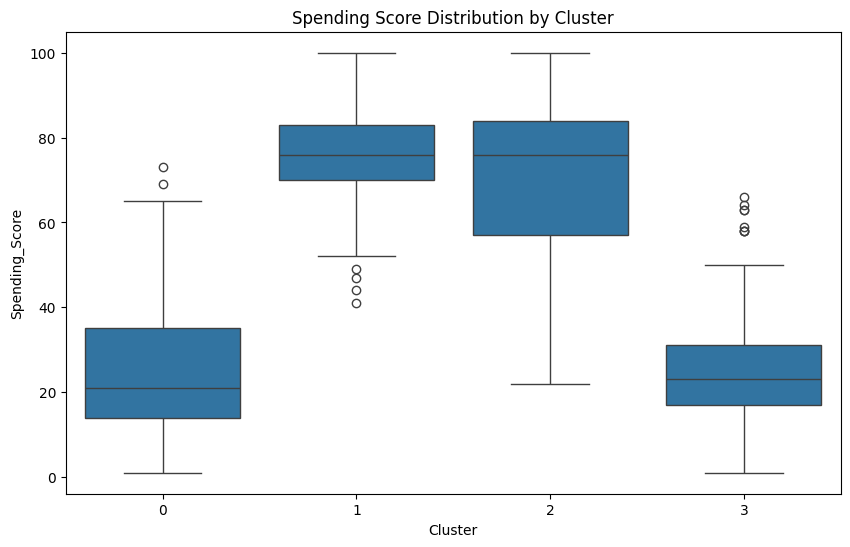

In [61]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Cluster',
    y='Spending_Score'
)

plt.title("Spending Score Distribution by Cluster")

plt.show()

# STEP 39 — Income vs Spending by Cluster

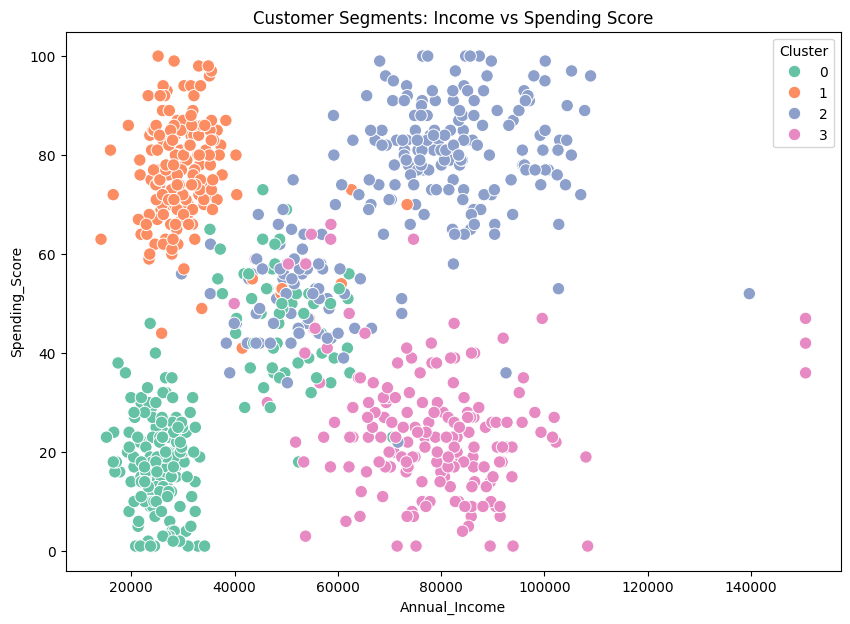

In [62]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title("Customer Segments: Income vs Spending Score")

plt.show()

# STEP 40 — Age vs Spending

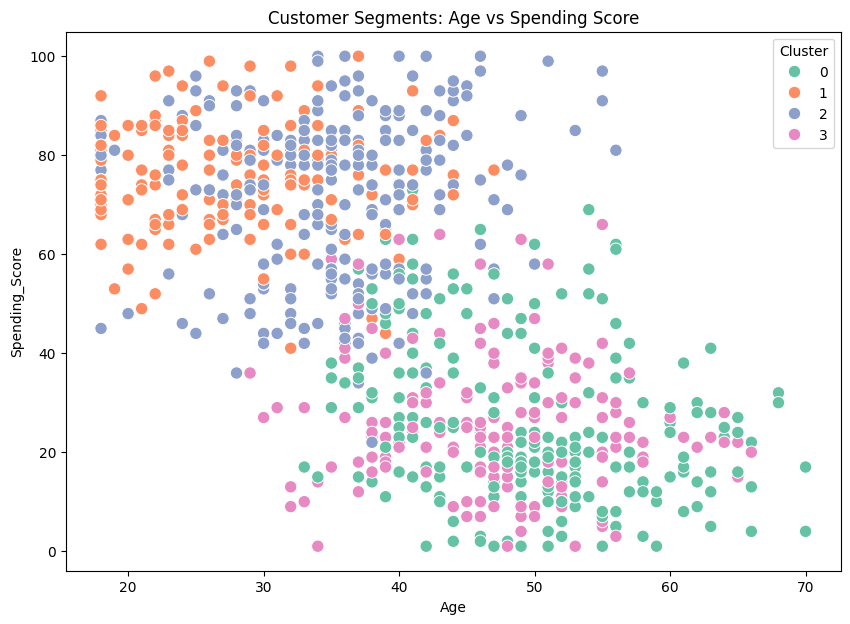

In [63]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Score',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title("Customer Segments: Age vs Spending Score")

plt.show()

# STEP 41 — Visits vs Spending

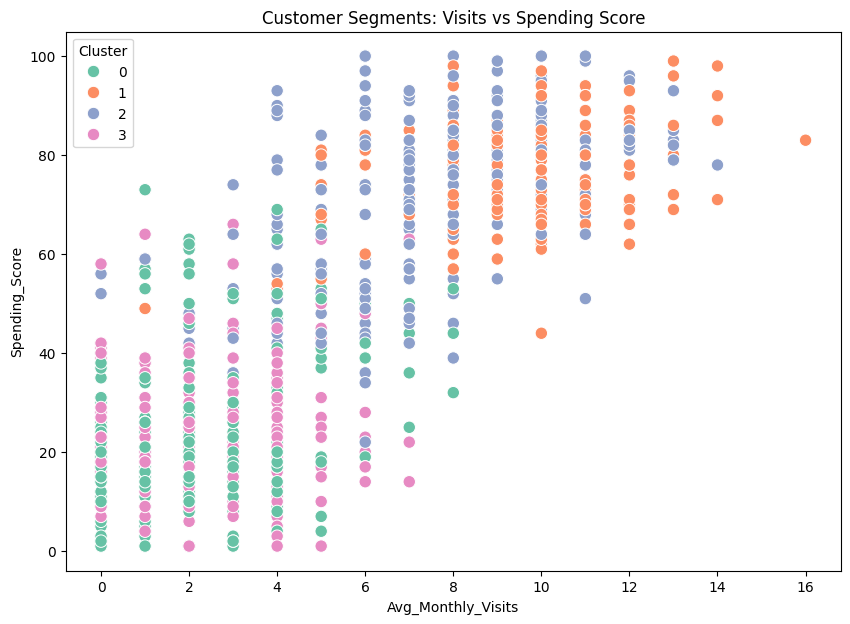

In [64]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Avg_Monthly_Visits',
    y='Spending_Score',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title("Customer Segments: Visits vs Spending Score")

plt.show()

# STEP 42 — Cluster Heatmap

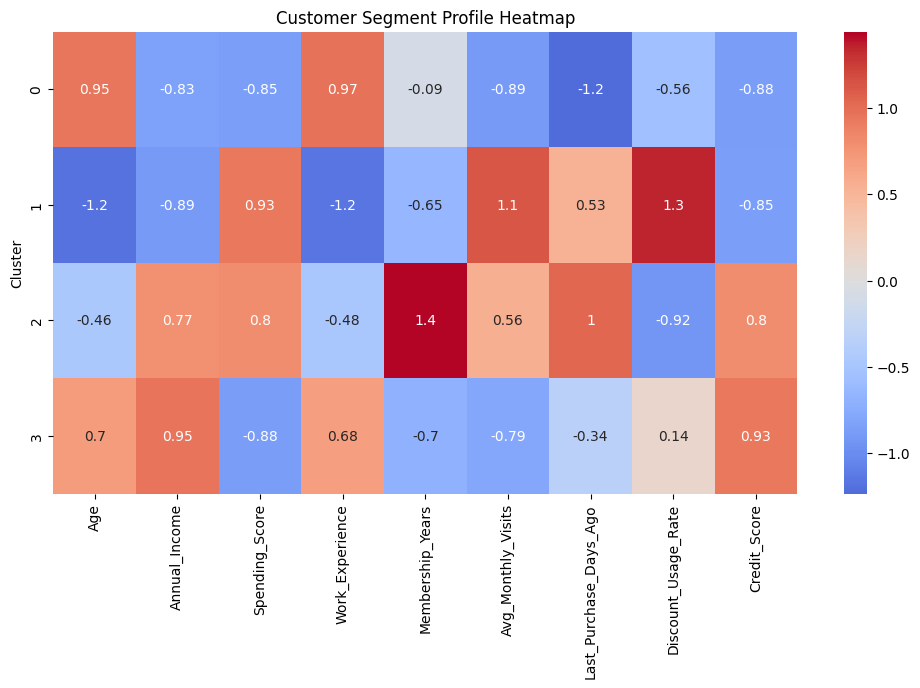

In [65]:
profile_for_heatmap = df.groupby('Cluster')[
    [
        'Age',
        'Annual_Income',
        'Spending_Score',
        'Work_Experience',
        'Membership_Years',
        'Avg_Monthly_Visits',
        'Last_Purchase_Days_Ago',
        'Discount_Usage_Rate',
        'Credit_Score'
    ]
].mean()

# Standardize profile values for visualization
profile_scaled = (
    profile_for_heatmap -
    profile_for_heatmap.mean()
) / profile_for_heatmap.std()

plt.figure(figsize=(12, 6))

sns.heatmap(
    profile_scaled,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Customer Segment Profile Heatmap")

plt.show()

# STEP 43 — Give Business-Friendly Names

In [67]:
#The machine-learning algorithm gives us: Cluster 0, Cluster 1, Cluster 2, Cluster 3.

But we need High-Value Loyal Customers

Budget-Conscious Customers

Young Potential Customers

In [69]:
#So, we need to check cluster_profile

In [68]:
cluster_profile

,Age,Annual_Income,Spending_Score,Work_Experience,Family_Size,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,Discount_Usage_Rate,Credit_Score,Customer_Count
Cluster,,,,,,,,,,,
0,49.64,31856.65,25.42,26.79,1.92,3.04,2.26,15.72,21.24,663.13,218
1,27.82,30364.98,75.84,6.59,1.30,2.99,9.37,19.62,54.18,663.54,169
2,35.21,73674.72,72.08,13.04,3.10,3.17,7.36,20.73,15.05,691.61,238
3,47.14,78327.71,24.77,24.05,5.26,2.98,2.61,17.70,33.29,693.90,175


# Then we have to decide names based on the actual characteristics.

In [70]:
cluster_names = {
    0: 'High-Value Loyal Customers',
    1: 'Budget-Conscious Customers',
    2: 'Young High-Spending Customers',
    3: 'Low-Engagement Customers'
}

# STEP 44 — Add Business Segment Name

In [71]:
df['Segment_Name'] = df['Cluster'].map(cluster_names)

df[
    [
        'CustomerID',
        'Cluster',
        'Segment_Name'
    ]
].head(20)

,CustomerID,Cluster,Segment_Name
0,1,2,Young High-Spending Customers
1,2,1,Budget-Conscious Customers
2,3,2,Young High-Spending Customers
3,4,2,Young High-Spending Customers
4,5,2,Young High-Spending Customers
5,6,1,Budget-Conscious Customers
6,7,1,Budget-Conscious Customers
7,8,0,High-Value Loyal Customers
8,9,2,Young High-Spending Customers
9,10,0,High-Value Loyal Customers


# STEP 45 — Create a Marketing Strategy Dictionary

In [72]:
marketing_strategy = {
    'High-Value Loyal Customers':
        'VIP membership, premium products, exclusive offers and early access',

    'Budget-Conscious Customers':
        'Discounts, coupons, bundle offers and price-sensitive promotions',

    'Young High-Spending Customers':
        'Social media campaigns, trending products and personalized digital promotions',

    'Low-Engagement Customers':
        'Reactivation campaigns, personalized offers and limited-time incentives'
}

# STEP 46 — Add Strategy to Segment Summary

In [73]:
segment_summary = cluster_profile.reset_index()

segment_summary['Segment_Name'] = segment_summary['Cluster'].map(
    cluster_names
)

segment_summary['Marketing_Strategy'] = segment_summary[
    'Segment_Name'
].map(marketing_strategy)

segment_summary

,Cluster,Age,Annual_Income,Spending_Score,Work_Experience,Family_Size,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,Discount_Usage_Rate,Credit_Score,Customer_Count,Segment_Name,Marketing_Strategy
0,0,49.64,31856.65,25.42,26.79,1.92,3.04,2.26,15.72,21.24,663.13,218,High-Value Loyal Customers,"VIP membership, premium products, exclusive of..."
1,1,27.82,30364.98,75.84,6.59,1.30,2.99,9.37,19.62,54.18,663.54,169,Budget-Conscious Customers,"Discounts, coupons, bundle offers and price-se..."
2,2,35.21,73674.72,72.08,13.04,3.10,3.17,7.36,20.73,15.05,691.61,238,Young High-Spending Customers,"Social media campaigns, trending products and ..."
3,3,47.14,78327.71,24.77,24.05,5.26,2.98,2.61,17.70,33.29,693.90,175,Low-Engagement Customers,"Reactivation campaigns, personalized offers an..."


# STEP 47 — Hierarchical Clustering Comparison

In [74]:
hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(
    X_processed
)

hierarchical_score = silhouette_score(
    X_processed,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_score, 4)
)

Hierarchical Clustering Silhouette Score: 0.1396


# Now we have to compare the results

In [75]:
kmeans_score = silhouette_score(
    X_processed,
    cluster_labels
)

print("K-Means Silhouette Score:",
      round(kmeans_score, 4))

print("Hierarchical Silhouette Score:",
      round(hierarchical_score, 4))

K-Means Silhouette Score: 0.1577
Hierarchical Silhouette Score: 0.1396


# STEP 48 —  DBSCAN
# We can include DBSCAN as an advanced comparison.

In [76]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(
    X_processed
)

print(
    "Number of clusters:",
    len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)

print(
    "Number of noise points:",
    list(dbscan_labels).count(-1)
)

Number of clusters: 0
Number of noise points: 800


# STEP 49 — Final Customer Dataset

In [77]:
final_dataset = df.copy()

final_dataset.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family_Size,Marital_Status,Preferred_Category,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,City_Tier,Discount_Usage_Rate,Credit_Score,Cluster,Segment_Name
0,1,Male,48,95857,78,Homemaker,30.0,2,Single,Home & Living,0.0,14,46,3,13.7,689,2,Young High-Spending Customers
1,2,Female,37,31914,89,Homemaker,15.0,2,Divorced,Fashion,1.8,12,7,1,50.1,686,1,Budget-Conscious Customers
2,3,Female,33,76710,68,Teacher,12.0,2,Single,Groceries,5.1,11,2,2,1.1,729,2,Young High-Spending Customers
3,4,Male,37,82276,93,Artist,14.0,3,Single,Electronics,3.4,7,50,2,15.5,663,2,Young High-Spending Customers
4,5,Female,32,67215,83,Homemaker,9.0,3,Married,Home & Living,1.5,10,62,2,10.8,666,2,Young High-Spending Customers


# STEP 50 — Sort by Segment

In [78]:
final_dataset = final_dataset.sort_values(
    by='Cluster'
)

final_dataset.head(20)

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work_Experience,Family_Size,Marital_Status,Preferred_Category,Membership_Years,Avg_Monthly_Visits,Last_Purchase_Days_Ago,City_Tier,Discount_Usage_Rate,Credit_Score,Cluster,Segment_Name
797,798,Female,60,46917,29,Doctor,37.0,3,Married,Travel,3.1,2,92,3,13.2,683,0,High-Value Loyal Customers
769,770,Female,51,24377,10,Teacher,30.0,1,Single,Travel,5.3,2,39,1,15.9,679,0,High-Value Loyal Customers
768,769,Female,47,23295,13,Engineer,28.0,1,Single,Beauty,2.1,3,12,2,34.1,672,0,High-Value Loyal Customers
29,30,Male,41,26265,24,Retired,21.0,2,Married,Beauty,2.3,2,25,2,0.8,659,0,High-Value Loyal Customers
26,27,Male,50,23805,9,Entrepreneur,30.0,1,Married,Travel,2.0,4,0,1,21.3,676,0,High-Value Loyal Customers
24,25,Male,63,21315,5,Executive,36.0,1,Married,Travel,2.9,0,37,2,13.8,664,0,High-Value Loyal Customers
20,21,Female,61,17757,16,Artist,34.0,1,Single,Beauty,2.8,0,10,2,21.0,672,0,High-Value Loyal Customers
17,18,Male,41,20659,27,Retired,20.0,2,Single,Electronics,0.5,4,4,2,32.9,604,0,High-Value Loyal Customers
799,800,Male,43,43302,51,Retired,20.0,2,Married,Electronics,1.1,5,2,1,22.9,654,0,High-Value Loyal Customers
7,8,Female,48,23337,13,Homemaker,25.0,3,Single,Travel,5.8,4,11,2,34.6,750,0,High-Value Loyal Customers


STEP 51 — Exporting Final Dataset

In [79]:
final_dataset.to_csv(
    'Customer_Segmentation_Final.csv',
    index=False
)

print("Final dataset exported successfully!")

Final dataset exported successfully!


# Download it:

In [80]:
from google.colab import files

files.download(
    'Customer_Segmentation_Final.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# STEP 52 — Export Segment Summary

In [81]:
segment_summary.to_csv(
    'Customer_Segment_Summary.csv',
    index=False
)

files.download(
    'Customer_Segment_Summary.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# STEP 53 — Creating an Excel Report

In [82]:
with pd.ExcelWriter(
    'Customer_Segmentation_Report.xlsx',
    engine='openpyxl'
) as writer:

    final_dataset.to_excel(
        writer,
        sheet_name='Customer_Data',
        index=False
    )

    segment_summary.to_excel(
        writer,
        sheet_name='Segment_Summary',
        index=False
    )

    cluster_evaluation.to_excel(
        writer,
        sheet_name='Model_Evaluation',
        index=False
    )

    category_profile.to_excel(
        writer,
        sheet_name='Category_Profile'
    )

    profession_profile.to_excel(
        writer,
        sheet_name='Profession_Profile'
    )

print("Excel report created successfully!")

Excel report created successfully!


# Download it!

In [83]:
files.download(
    'Customer_Segmentation_Report.xlsx'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>